# Lecture 3 — Policies, Timing, Populations
## 第三讲 —— 策略、时序、群体

**Computational Methods for Heterogeneous-Agent Macro**
**异质性主体宏观的计算方法**

Jeffrey Sun


### Environment
### 运行环境


In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()
using Plots, Random, LinearAlgebra

  Activating project at `~/projects/research/CV is all you need`


# Core Code
# 核心代码


### Parameters

In [2]:
u(c) = c <= 0 ? -Inf : log(c)
loggrid(lo, hi, N) = exp.(range(log(lo), log(hi); length = N))

loggrid (generic function with 1 method)

In [4]:
function get_params(;
        β=0.96,
        R=1.04,
        w=1.0,
        b_grid = loggrid(0.05, 200.0, 400),
        w_grid = [2.7, 2.6, 2.5],
        Π      = [0.95 0.04 0.01;
                  0.05 0.9  0.05;
                  0.01 0.04 0.95],
    )

    return params = (;β, R, w,
                    V_shape=(length(b_grid), length(w_grid)),
                    b_grid, w_grid, Π)
end

get_params (generic function with 1 method)

In [5]:
params = get_params(; β=0.90)

(β = 0.9, R = 1.04, w = 1.0, V_shape = (400, 3), b_grid = [0.05000000000000001, 0.05105023241317379, 0.05212252458878116, 0.05321733988437287, 0.05433515139016193, 0.05547644213345498, 0.056641705287377234, 0.05783144438398204, 0.05904617353183631, 0.06028641763817668  …  165.87484199206176, 169.35898470386456, 172.9163106078285, 176.54835689116376, 180.2566930291573, 184.04292146337195, 187.90867829409248, 191.8556339873144, 195.88549409658413, 199.99999999999991], w_grid = [2.7, 2.6, 2.5], Π = [0.95 0.04 0.01; 0.05 0.9 0.05; 0.01 0.04 0.95])

### Markov Income
### 马尔可夫收入

Income takes two values — employed ($y = 1.0$) or unemployed ($y = 0.3$) — with row-stochastic transition matrix
$$
\Pi \;=\; \begin{pmatrix} 0.95 & 0.05 \\ 0.50 & 0.50 \end{pmatrix}.
$$
Long-run employment share $\approx 0.91$; mean unemployment spell $= 2$ periods.

收入取两个值——就业 ($y = 1.0$) 与失业 ($y = 0.3$)——行随机转移矩阵
$$
\Pi \;=\; \begin{pmatrix} 0.95 & 0.05 \\ 0.50 & 0.50 \end{pmatrix}.
$$
长期就业占比约为 $0.91$，失业平均持续 $2$ 期。


### Utility and Log Grid
### 效用函数与对数网格

### Simple Discretized Grid Functions
These functions are as simple as possible for clarity. In reality, they leave a lot to be desired: interpolation, better performance, etc.

In [6]:
"""
Snap a value `x` to the nearest grid index.

把数值 `x` 落到最近的网格下标。
"""
snap_idx(grid, x) = argmin(abs.(grid .- x))

snap_idx

In [7]:
closest_b_ind = snap_idx(params.b_grid, 186.05)

params.b_grid[closest_b_ind]

187.90867829409248

### Backward iteration in stages
### 分阶段后向迭代

The three stages compose into one backward step on a 2-D value function
$V \in \mathbb{R}^{N_b \times N_w}$. Each stage maps one labelled $V$ to the next:

- **Stage 3 (Consumption-Saving) backward.** Grid-search $V^{\mathrm{end}} \mapsto V$.
- **Stage 2 (Income) backward.** Lookup $V \mapsto V^{\mathrm{start}}_{\mathrm{post}}$ at $R\,b^{\mathrm{end}} + w_vals[j]$.
- **Stage 1 (Income Shock) backward.** Matrix-multiply $V^{\mathrm{start}}_{\mathrm{post}} \mapsto V^{\mathrm{start}}_{\mathrm{pre}}$ by $\Pi^\top$.

At the period boundary, $V^{\mathrm{end}} = \beta\, V^{\mathrm{start}}_{\mathrm{pre}}$.

三个阶段合在一起就是 2 维价值函数 $V \in \mathbb{R}^{N_b \times N_w}$ 的一次后向更新。每个阶段把一个 $V$ 映到下一个：

- **第三阶段（后向）。** 网格搜索 $V^{\mathrm{end}} \mapsto V$。
- **第二阶段（后向）。** 在 $R\,b^{\mathrm{end}} + w_vals[j]$ 上查表 $V \mapsto V^{\mathrm{start}}_{\mathrm{post}}$。
- **第一阶段（后向）。** 用 $\Pi^\top$ 做矩阵乘法 $V^{\mathrm{start}}_{\mathrm{post}} \mapsto V^{\mathrm{start}}_{\mathrm{pre}}$。

期界过渡：$V^{\mathrm{end}} = \beta\, V^{\mathrm{start}}_{\mathrm{pre}}$。


In [ ]:
"""
Stage 1 (Income Shock) backward: V_start = V_pre_inc * Π'.

第一阶段（后向）：V_start = V_pre_inc * Π'。
"""
income_shock_backward(V_post_inc_shock, params) = V_post_inc_shock * params.Π'

"""
Stage 2 (Income) backward: V_pre_inc(b_end, w) = V(R*b_end + w, w), snapped to nearest grid.
Fully broadcast — no explicit loop.

第二阶段（后向）：V_pre_inc(b_end, w) = V(R*b_end + w, w)，落到最近的网格点。
全部用广播——没有显式循环。
"""
function income_backward(V_post_inc, params)
    (; R, w_grid, b_grid) = params
    b_post_inc = snap_idx.(Ref(b_grid), R .* b_grid .+ w_grid')
    return V_pre_inc = V_post_inc[CartesianIndex.(b_post_inc, axes(b_post_inc, 2)')]
end


consumption_saving_backward

In [ ]:
params = get_params()

(; R, w_grid, b_grid) = params
b_post_inc = snap_idx.(Ref(b_grid), R .* b_grid .+ w_grid')

# Each entry of b_post_inc is end-of-stage-2 wealth (b) index
# b_post_inc 的每一项是第二阶段末（收入实现后）的财富 (b) 下标


In [ ]:

"""
Stage 3 (Consumption-Saving) backward: grid-search V_end → V over b_end choices.

第三阶段（消费--储蓄）后向：在 b_end 上做网格搜索，V_end → V。
"""
function consumption_saving_backward(V_end, params)
    # Unpack b_grid
    # 取出 b_grid
    (;b_grid) = params
    
    # Move b_grid to dimension 3 to represent b_end choices
    # 把 b_grid 移到第 3 维，作为 b_end 的候选
    b_next_grid = insertdims(b_grid; dims=(1,2))

    # Move b_grid part of V_end to dimension 3 to represent b_end choices
    # V_end_reshape shape is now [1, w_grid, b_grid]
    # 把 V_end 中对应 b_grid 的轴也搬到第 3 维（形状变为 [1, w_grid, b_grid]）
    V_end_reshape = insertdims(permutedims(V_end, (2,1)); dims=1)

    # Maximize along b_end dimension (dim=3)
    # 沿 b_end 维（第 3 维）取最大值
    V = maximum(u.(b_grid .- b_next_grid) .+ V_end_reshape; dims=3)

    # Drop dimension 3 from V and return
    # 去掉第 3 维并返回
    return dropdims(V; dims=3)
end

In [ ]:
V_end = zeros(params.V_shape)
@show size(V_end)

(;b_grid) = params #b_grid = params.b_grid

b_next_grid = insertdims(b_grid; dims=(1,2))
@show size(b_next_grid)

@show size(V_end)
V_end_reshape = permutedims(insertdims(V_end; dims=3), (3,2,1))
@show size(V_end_reshape)

objective = u.(b_grid .- b_next_grid) .+ V_end_reshape
@show size(objective)

V_pre_consume = maximum(objective; dims=3)
@show size(V_pre_consume)

dropdims(V_pre_consume; dims=3)


size(V_end) = (400, 3)
size(b_next_grid) = (1, 1, 400)
size(V_end) = (400, 3)
size(V_end_reshape) = (1, 3, 400)
size(objective) = (400, 3, 400)
size(V_pre_consume) = (400, 3, 1)


1×1×400 Array{Float64, 3}:
[:, :, 1] =
 0.05000000000000001

[:, :, 2] =
 0.05105023241317379

[:, :, 3] =
 0.05212252458878116

;;; … 

[:, :, 398] =
 191.8556339873144

[:, :, 399] =
 195.88549409658413

[:, :, 400] =
 199.99999999999991

In [ ]:
function bellman_operator(V_end, params)
    (;β) = params
    # Stage 3
    # 第三阶段
    V_post_inc = consumption_saving_backward(V_end, params)

    # Stage 2
    # 第二阶段
    V_post_inc_shock = income_backward(V_post_inc, params)

    # Stage 1
    # 第一阶段
    V_start = income_shock_backward(V_post_inc_shock, params)

    # Passage of time
    # 时间流逝
    V_end_new = β .* V_start
    return V_end_new
end

In [12]:
params = get_params()
V_end = zeros(params.V_shape)
V_end_new = bellman_operator(V_end, params)

400×3 Matrix{Float64}:
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 0.955555  0.917331  0.879079
 ⋮                   
 4.98634   4.98634   4.98634
 5.0063    5.0063    5.0063
 5.02626   5.02626   5.02626
 5.04622   5.04622   5.04622
 5.06618   5.06618   5.06618
 5.08595   5.08515   5.06718
 5.08614   5.08614   5.08614
 5.08614   5.08614   5.08614
 5.08614   5.08614   5.08614

### Value Function Iteration (Same as L2!)
### 价值函数迭代（沿用 L2）

Iterate $V \mapsto \mathcal{T}V$ until the max-abs change drops below `tol`.

反复迭代 $V \mapsto \mathcal{T}V$，直到最大绝对变化小于 `tol`。


In [14]:
function solve_vfi(params; tol = 1e-6, maxiter = 2000, verbosity = 0)
    V = zeros(params.V_shape)

    Δ, iters = Inf, 0
    while Δ >= tol
        TV = bellman_operator(V, params)
        Δ  = maximum(abs.(TV .- V))
        V  = TV
        iters += 1
        iters > maxiter && error("VFI did not converge in $maxiter iterations")
    end

    verbosity >= 1 && println("VFI converged in $iters iterations with error $Δ")
    return V
end

solve_vfi (generic function with 1 method)

In [15]:
params = get_params()
V_end = solve_vfi(params; verbosity = 1)

VFI converged in 356 iterations with error 9.84368959677795e-7


400×3 Matrix{Float64}:
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
 23.6723  23.2872  22.8984
  ⋮                
 57.7003  57.7003  57.7003
 58.1111  58.1111  58.1111
 58.5182  58.5182  58.5182
 58.9215  58.9215  58.9215
 59.3208  59.3208  59.3208
 59.6664  59.596   59.3358
 59.6692  59.6103  59.6077
 59.6692  59.6103  59.6077
 59.6692  59.6103  59.6077

### A Population is an Array (Vector, Matrix, etc.)
### 群体即向量

A *population* can be thought of as a *distribution* over state variables.

If $b$ is the only state variable, then a *population* is just a vector $\lambda$, with $\lambda_i$ = "number of people with wealth $b_i$."

If $(b, w)$ are the state variables, the population is a matrix $\lambda$, with $\lambda_{ij}$ = "number of people with wealth $b_i$ and income $w_j$."

*群体*可视为状态变量上的一个*分布*。

若 $b$ 是唯一的状态变量，则*群体*就是一个向量 $\lambda$，其中 $\lambda_i$ 表示“财富为 $b_i$ 的人数”。

若 $(b, w)$ 是状态变量，则群体是一个矩阵 $\lambda$，其中 $\lambda_{ij}$ 表示“财富为 $b_i$ 且收入为 $w_j$ 的人数”。


### Forward iteration in stages
### 分阶段前向迭代

We can simulate each population matrix forward though each stage, one at a time.

- **Stage 1 (Income Shock) forward.** $\lambda \mapsto \lambda\, \Pi$.
- **Stage 2 (Income) forward.** Each $(b^{\mathrm{end}}, w)$ cell moves to $(R\,b^{\mathrm{end}} + w_vals[j],\, w)$.
- **Stage 3 (Consumption-Saving) forward.** Each $(b, w)$ cell moves to $(b - c^\star(b, w),\, w)$.

Both wealth re-bins snap to the nearest grid point.

三个阶段也可以合成 2 维分布 $\lambda \in \mathbb{R}^{N_b \times N_w}$ 的一次*前向*更新：

- **第一阶段（前向）。** $\lambda \mapsto \lambda\, \Pi$。
- **第二阶段（前向）。** 每个 $(b^{\mathrm{end}}, w)$ 单元移到 $(R\,b^{\mathrm{end}} + w_vals[j],\, w)$。
- **第三阶段（前向）。** 每个 $(b, w)$ 单元移到 $(b - c^\star(b, w),\, w)$。

两次沿财富维的重排都落到最近的网格点。


In [ ]:
"""
Stage 1 forward: λ_post = λ_pre * Π.

第一阶段（前向）：λ_post = λ_pre * Π。
"""
income_shock_forward(λ, Π) = λ * Π

"""
Stage 2 forward: each (i_b_end, i_w) cell moves to (snap(R*b_end + w), i_w).
Vectorize the destination index via broadcasting; one tight scatter.

第二阶段（前向）：每个 (i_b_end, i_w) 单元移到 (snap(R*b_end + w), i_w)。
目标下标用广播算出；一次紧凑散布。
"""

function change_λ_wealth(λ, b_inds_new)
    λ_new = zero(λ)
    for old_idx in CartesianIndices(λ)
        λ_new[b_inds_new[old_idx], old_idx[2]] += λ[old_idx]
    end
    return λ_new
end

function income_forward(λ, params)
    (; R, w_grid, b_grid) = params
    dest = snap_idx.(Ref(b_grid), R .* b_grid .+ w_grid')               # (N_b, N_w)
    return change_λ_wealth(λ, dest)
end

"""
Stage 3 forward: each (i_b, i_w) cell moves to (c_ind[i_b, i_w], i_w).
c_ind is exactly the destination index — direct scatter.

第三阶段（前向）：每个 (i_b, i_w) 单元移到 (c_ind[i_b, i_w], i_w)。
c_ind 本身就是目标下标——直接散布。
"""
function policy_function(V_end, params)
    # Unpack b_grid
    # 取出 b_grid
    (;b_grid) = params
    
    # Move b_grid to dimension 3 to represent b_end choices
    # 把 b_grid 移到第 3 维，作为 b_end 的候选
    b_next_grid = insertdims(b_grid; dims=(1,2))

    # Move b_grid part of V_end to dimension 3 to represent b_end choices
    # V_end_reshape shape is now [1, w_grid, b_grid]
    # 把 V_end 中对应 b_grid 的轴搬到第 3 维（形状变为 [1, w_grid, b_grid]）
    V_end_reshape = insertdims(permutedims(V_end, (2,1)); dims=1)

    # Maximize along b_end dimension (dim=3)
    # 沿 b_end 维（第 3 维）取 argmax
    policy_idxs = argmax(u.(b_grid .- b_next_grid) .+ V_end_reshape; dims=3)

    return [idx[3] for idx in policy_idxs[:,:,1]]
end

consumption_saving_forward(λ, b_inds_new, params) = change_λ_wealth(λ, b_inds_new)

"""
One forward step of the composite operator T*:
λ → income shock → income → consumption saving.

复合算子 T* 的一次前向更新：λ → 收入冲击 → 收入 → 消费储蓄。
"""
function simulate_population_forward(λ, b_inds_new, params)
    # Stage 1
    # 第一阶段
    λ = income_shock_forward(λ, params.Π)

    # Stage 2
    # 第二阶段
    λ = income_forward(λ, params)

    # Stage 3
    # 第三阶段
    λ = consumption_saving_forward(λ, b_inds_new, params)
    
    return λ
end


In [ ]:
params = get_params()
V_end = solve_vfi(params; verbosity = 1)
b_inds_new = policy_function(V_end, params)

# Guess λ
# 初始猜测 λ
λ_start = fill(1/length(params.V_shape), params.V_shape)
@show sum(λ_start)


In [39]:
function find_steady_state_population(V_end, params; tol = 1e-5, maxiter = 10_000, verbosity = 0)

    b_inds_new = policy_function(V_end, params)
    
    λ = fill(1/length(params.V_shape), params.V_shape) # Start with households evenly distributed across gridpoints

    Δ, iters = Inf, 0
    while Δ >= tol
        λ_new = simulate_population_forward(λ, b_inds_new, params)
        Δ = maximum(abs.(λ_new .- λ))
        λ = λ_new
        iters += 1
        iters > maxiter && error("Steady state λ did not converge in $maxiter iterations")
    end

    verbosity >= 1 && println("Steady state λ converged in $iters iterations with error $Δ")
    return λ
end

find_steady_state_population (generic function with 1 method)

In [42]:
params = get_params()
V_end = solve_vfi(params; verbosity = 1)
λ_steady_state = find_steady_state_population(V_end, params; verbosity=1)

VFI converged in 356 iterations with error 9.84368959677795e-7
Steady state λ converged in 1141 iterations with error 9.986706672331569e-6


400×3 Matrix{Float64}:
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  ⋮                  
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
 18.2125      14.57  18.2125
  8.1332e-26   0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0
  0.0          0.0    0.0

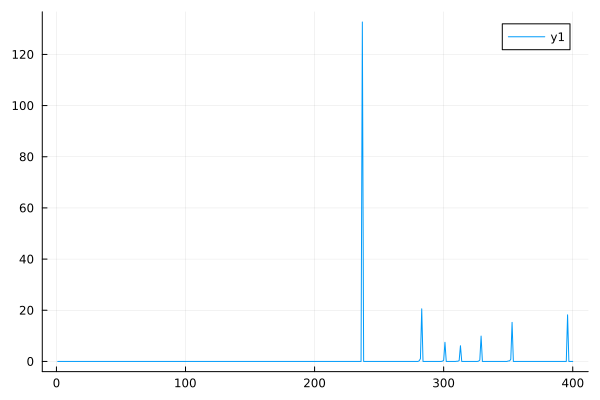

In [43]:
plot(vec(λ_steady_state[:,1]))

## Demo
## 演示

Set up parameters, solve the value function, read off the policy, and run both simulators.

设好参数，解出价值函数，读出策略，然后跑两个模拟器。


In [ ]:
params = get_params()
V_end = solve_vfi(params; verbosity = 1)
b_inds_new = policy_function(V_end, params)

λ_start = fill(1/length(params.V_shape), params.V_shape)
λ_next = simulate_population_forward(λ_start, b_inds_new, params)
;

### Plot $V$ and $c^\star$
### 画出 $V$ 与 $c^\star$


In [ ]:
(;b_grid, w_grid) = params
params = get_params(;)
V_end = solve_vfi(params; verbosity = 1)
b_inds_new = policy_function(V_end, params)

# turn the index vector b_inds_new back into a consumption value for plotting:
c_pol = b_grid .- b_grid[b_inds_new]

p1 = plot(b_grid, V_end; lw = 2, xlabel = "wealth b", ylabel = "V(b)",
          label = ["high income", "medium income", "low income"], legend = :bottomright)
p2 = plot(b_grid, c_pol; lw = 2, xlabel = "wealth b", ylabel = "c*(b)",
          label = "c*", legend = :bottomright)
plot!(p2, b_grid, b_grid; ls = :dash, lw = 1, label = "45°")
plot(p1, p2; layout = (1, 2), size = (1000, 320))


### Simulate one household
### 模拟一户

Roll a single household forward over time. Wealth drifts up during employment spells and drops when income switches to unemployment.

把单户向前推若干期。就业期间财富缓慢攀升，失业时下落。


In [ ]:
"""
Draw the next state of a Markov chain with row-stochastic Π, given current state i.

给定当前状态 i 与行随机转移矩阵 Π，抽取下一状态。
"""
sample_markov(Π, i) = findfirst(rand() .<= cumsum(Π[i, :]))

"""
Roll one household forward T periods using the policy index matrix `c_inds`.
Each period applies Stage 1 (Markov on income), Stage 2 (cash-on-hand
b = R·b_end + w), Stage 3 (savings = policy lookup at (b, w)). The recorded
`i_b_path[t]` is cash-on-hand at t (wealth after income realizes).

用策略下标矩阵 `c_inds` 将单户向前推 T 期。每期依次应用：第一阶段
（收入上的马尔可夫），第二阶段（现金 b = R·b_end + w），第三阶段
（在 (b, w) 处查策略得到储蓄）。记录的 `i_b_path[t]` 为期 t 的
现金（即收入实现后的财富）。
"""
function simulate_one(c_inds, params; T = 200, b_ind_init = 1, w_ind_init = 1)
    (; R, w_grid, Π, b_grid) = params

    # State carried across iterations: end-of-period savings index `b_ind`
    # (b_end) and current income state `w_ind`. A fresh income shock is drawn
    # first each period, matching the timing of the backward Bellman.
    # 迭代间携带的状态：期末储蓄下标 b_ind（即 b_end）与当前收入状态 w_ind。
    # 每期先抽取新的收入冲击，与后向 Bellman 的时序保持一致。
    b_ind, w_ind = b_ind_init, w_ind_init

    i_b_path, i_w_path = zeros(Int, T), zeros(Int, T)
    for t in 1:T
        # Stage 1: income shock — draw next income state.
        # 第一阶段：收入冲击——抽取下一期的收入状态。
        w_ind = sample_markov(Π, w_ind)

        # Stage 2: realize income, assemble cash-on-hand b = R·b_end + w.
        # 第二阶段：实现收入，组装现金 b = R·b_end + w。
        b_cash_ind = snap_idx(b_grid, R * b_grid[b_ind] + w_grid[w_ind])

        # Stage 3: savings = policy at (cash-on-hand, income).
        # 第三阶段：在 (现金, 收入) 处查策略得到储蓄。
        b_ind = c_inds[b_cash_ind, w_ind]

        i_b_path[t], i_w_path[t] = b_cash_ind, w_ind
    end
    return (; i_b_path, i_w_path)
end

In [ ]:
(;b_grid, w_grid) = params
params = get_params(;)
V_end = solve_vfi(params; verbosity = 1)
b_inds_new = policy_function(V_end, params)


Random.seed!(1)
# start at the grid point nearest to wealth 1.0, employed
# 初始位置：最接近财富 1.0 的网格点；就业状态
sim = simulate_one(b_inds_new, params; T = 300,
                   b_ind_init = argmin(abs.(b_grid .- 1.0)), w_ind_init = 1)

t_axis = 1:length(sim.i_b_path)
p1 = plot(t_axis, b_grid[sim.i_b_path]; lw = 1.5,
          xlabel = "t", ylabel = "wealth b_t",
          label = "b_t", legend = :topright)
p2 = plot(t_axis, [w_grid[w] for w in sim.i_w_path]; lw = 1.5,
          xlabel = "t", ylabel = "income w_t",
          label = "w_t", legend = :topright, seriestype = :steppost)
plot(p1, p2; layout = (2, 1), size = (820, 420))


In [ ]:
# start everyone at wealth ≈ 1.0, employed
# 让所有人从财富 ≈ 1.0、就业状态出发
λ_0 = zeros(length(b_grid), length(w_grid))
i_0 = argmin(abs.(b_grid .- 1.0))
λ_0[i_0, 1] = 1.0

λ_path = simulate_population(c_ind, params, λ_0; T = 200)
;


In [ ]:
# marginal wealth distribution at four snapshots
# 几个时刻的财富边际分布
function wealth_marginal(λ)
    return vec(sum(λ; dims = 2))
end

snapshots = [1, 5, 25, 200]
p = plot(xlabel = "wealth b", ylabel = "density", legend = :topright)
for t in snapshots
    plot!(p, b_grid, wealth_marginal(λ_path[t]); lw = 1.8, label = "t = $(t-1)")
end
plot(p; size = (820, 320), xscale = :log10)


### Cross-sectional aggregates from $V$ and $c^\star$
### 从 $V$、$c^\star$ 直接读出横截面总量

Aggregate welfare $\bar V$, consumption $\bar C$, wealth $\bar K$ at each $t$ — all inner products against the marginal wealth distribution.

总福利 $\bar V$、总消费 $\bar C$、总财富 $\bar K$——都是与边际财富分布的内积。


In [ ]:
# inner products against the marginal wealth distribution
# 与边际财富分布的内积
V_bar = [dot(V,      wealth_marginal(λ)) for λ in λ_path]
C_bar = [dot(c_pol,  wealth_marginal(λ)) for λ in λ_path]
K_bar = [dot(b_grid, wealth_marginal(λ)) for λ in λ_path]

t_axis = 0:length(λ_path)-1
p1 = plot(t_axis, V_bar; lw = 1.8, xlabel = "t", ylabel = "V̄_t", label = "V̄")
p2 = plot(t_axis, C_bar; lw = 1.8, xlabel = "t", ylabel = "C̄_t", label = "C̄")
p3 = plot(t_axis, K_bar; lw = 1.8, xlabel = "t", ylabel = "K̄_t", label = "K̄")
plot(p1, p2, p3; layout = (1, 3), size = (1000, 280))


# Step-by-Step Explanation
# 分步讲解


### Policy via `argmax`, broken down
### 用 `argmax` 提取策略：分步看


In [ ]:
# the Bellman operator's matrix of values, one entry per (b, b') pair
# 贝尔曼算子内部那张 (b, b') 矩阵
b_end = (b_grid' .- params.w) ./ params.R
M     = u.(b_grid .- b_end) .+ params.β .* V'
size(M)


In [ ]:
# `argmax` along columns: for each row (each b), which column (b') is best?
# 对每一行（每个 b），最大值落在哪一列（哪个 b'）？
idx = argmax(M; dims = 2)
idx[1:5]      # CartesianIndex(i, j*) for the first five b


In [ ]:
# pull out just the column index — this is the chosen b'-index
# 只取出列下标——即所选的 b' 下标
j_star = vec(getindex.(idx, 2))
j_star[1:5]


In [ ]:
# the chosen b'-index for each b is exactly what policy_function returns
# 对每个 b，所选 b' 的下标正是 policy_function 返回的内容
c_ind_check = vec(getindex.(idx, 2))
maximum(abs.(c_ind_check .- c_ind))   # should be 0


### Markov along one dimension is matrix multiplication
### 沿一维做马尔可夫就是矩阵乘法

Take just the income marginal $\lambda_w$ (length 2). One Markov step is $\lambda_w \cdot \Pi$. After many steps the income share stops changing — this is the long-run share of employed/unemployed implied by $\Pi$.

只看收入边际 $\lambda_w$（长度 2）。一次马尔可夫步就是 $\lambda_w \cdot \Pi$。迭代多次后，收入占比不再变化——这就是 $\Pi$ 所对应的长期就业/失业比例。


In [ ]:
# start: everyone employed
# 起点：所有人都就业
λ_w_0 = [1.0  0.0]                         # row vector

# one step
# 一步
λ_w_1 = λ_w_0 * Π

# iterate forward many times; the income split settles to its long-run value
# 反复迭代多次；收入占比趋于其长期值
λ_w = let λ = λ_w_0
    for t in 1:200
        λ = λ * Π
    end
    λ
end

(long_run_employed = λ_w[1], long_run_unemployed = λ_w[2])


### Trace one household through the three stages
### 跟踪一户走过三阶段

Pick a single $(i_b, i_w)$ cell, draw a Markov step, then apply Stages 2--3 (the cash-on-hand assembly + index lookup) to see where its mass ends up.

挑一个 $(i_b, i_w)$ 单元，先做一次马尔可夫抽样，再做第二、第三阶段（装配现金 + 下标查找），看看它的质量去到哪里。


In [ ]:
# trace one (i_b, i_w) cell through Stages 1, 2, 3
# 追踪一个 (i_b, i_w) 单元穿过第一、第二、第三阶段
i_b, i_w = 50, 1

# Stage 1: a Markov draw advances the income state
# 第一阶段：一次 Markov 抽样推进收入状态
Random.seed!(42)
i_w_new = sample_markov(params.Π, i_w)

# Stage 2: assemble cash-on-hand b = R·b_end + w using the realized income, snap to grid
# 第二阶段：用实际收入装配现金 b = R·b_end + w，落到最近的网格下标
b_cash    = params.R * b_grid[i_b] + w_grid[i_w_new]
i_b_cash  = snap_idx(b_grid, b_cash)

# Stage 3: savings = policy lookup at (cash-on-hand, income)
# 第三阶段：在 (现金, 收入) 处查策略得到储蓄
i_b_new = b_inds_new[i_b_cash, i_w_new]
b_new   = b_grid[i_b_new]

(i_b = i_b, i_w = i_w, i_w_new = i_w_new,
 b_cash = b_cash, i_b_cash = i_b_cash,
 i_b_new = i_b_new, b_new = b_new)

Iterate the forward step many times. The wealth distribution settles into a long-run shape; aggregates read off as inner products with $V$, $c^\star$, and $b$.

反复应用前向算子。财富分布最终趋于一个长期形态；总量通过与 $V$、$c^\star$、$b$ 的内积读出。


In [ ]:
# start everyone at the same wealth and income, then apply the forward step
# many times — the distribution stops changing once we've iterated long enough.
# 让所有人从同一个财富与收入出发，反复应用前向算子；
# 迭代足够多次后，分布就不再变化。
λ_long_run = let λ = zeros(length(params.b_grid), length(params.w_vals))
    i_0 = argmin(abs.(params.b_grid .- 1.0))
    λ[i_0, 1] = 1.0
    for t in 1:400
        λ = forward_step(λ, c_ind_2d, params)
    end
    λ
end

# aggregates in the long run
# 长期下的总量
λ_w = vec(sum(λ_long_run; dims = 1))         # income marginal
λ_b = vec(sum(λ_long_run; dims = 2))         # wealth marginal

(employed_share = λ_w[1],
 mean_wealth    = dot(params.b_grid, λ_b),
 mean_V         = sum(V_2d .* λ_long_run))
